#Fraud Detection in financial transactions
This project analyses a cleaned 10000 records data set to uncover
patterns that indicate fraudulent activity and builds a
Logistic Regression model to classify transactions as
fraudulent or legitimate


In [ ]:
#Setup & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_excel('Fraud Case Study Dataset.xlsx')

print(f"Dataset shape: {df.shape}")
print(f"\nFraud breakdown:\n{df['is_fraud'].value_counts()}")
print(f"\nFraud rate: {df['is_fraud'].mean()*100:.2f}%")

Dataset shape: (10000, 27)

Fraud breakdown:
is_fraud
0    9500
1     500
Name: count, dtype: int64

Fraud rate: 5.00%


In [ ]:

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Duplicate rows: 0

Missing values per column:
transaction_id               0
user_id                      0
amount                       0
transaction_channel          0
merchant_clean               0
device_id                    0
card_type                    0
country                      0
timestamp                    0
prev_timestamp               0
lat                          0
lon                          0
prev_lat                     0
prev_lon                     0
time_since_last_tx           0
distance_from_last_tx        0
km_per_min                   0
device_change                0
velocity_last_10min          0
is_night                     0
merchant_risk_score          0
account_age_days             0
prior_chargebacks            0
high_risk_country            0
is_fraud                     0
Unnamed: 25              10000
Unnamed: 26               9999
dtype: int64

Data types:
transaction_id                    int64
user_id                          object
amount     

# Transaction Volume Vs Fraud Across Countries
A comparison of transaction volumes and fraud rates across the four countries in the dataset is done, UK, South Africa, Nigeria and Kenya. The left chart shows how evenly distributed transactions are across countries, while the right chart reveals that Nigeria and Kenya have notably higher fraud rates than the overall average, making them higher risk regions.

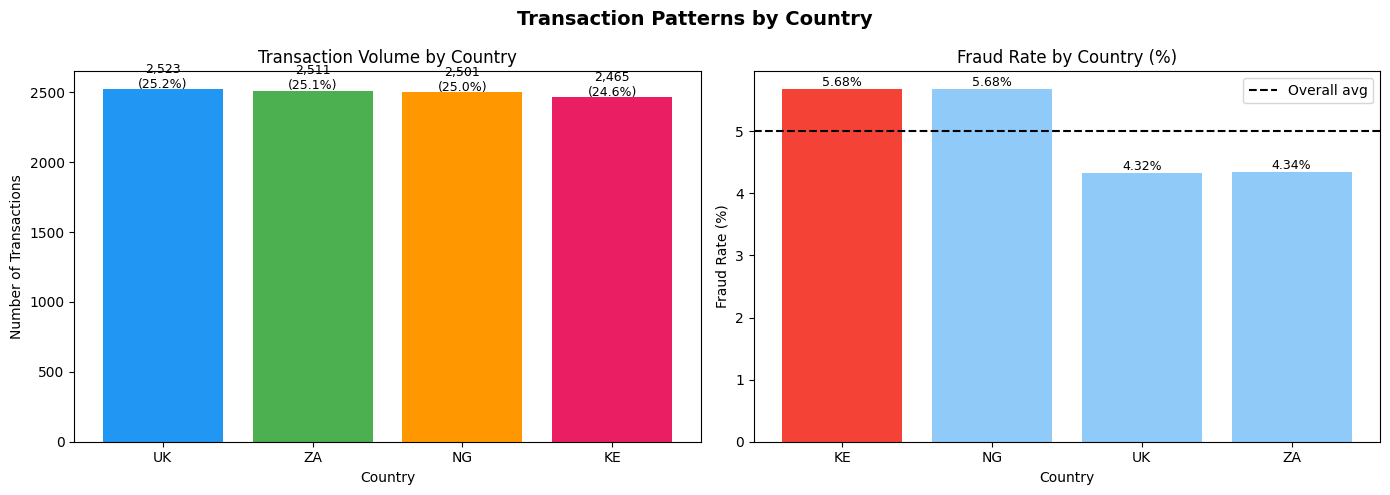


Key insight: NG and KE have the highest fraud rates at 5.68% each.


In [ ]:
#Country Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Patterns by Country', fontsize=14, fontweight='bold')

country_vol = df['country'].value_counts()
axes[0].bar(country_vol.index, country_vol.values, color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[0].set_title('Transaction Volume by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(country_vol.values):
    axes[0].text(i, v + 10, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

country_fraud = df.groupby('country')['is_fraud'].mean() * 100
colors = ['#f44336' if v == country_fraud.max() else '#90CAF9' for v in country_fraud.values]
axes[1].bar(country_fraud.index, country_fraud.values, color=colors)
axes[1].set_title('Fraud Rate by Country (%)')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(df['is_fraud'].mean()*100, color='black', linestyle='--', label='Overall avg')
axes[1].legend()
for i, v in enumerate(country_fraud.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print("\nKey insight: NG and KE have the highest fraud rates at 5.68% each.")

# Transaction Channel Analysis
This section looks at how transactions are made whether online, in-store, airtime, card-present or card-not-present. The airtime channel stands out with the highest fraud rate, which is worth flagging as a higher risk payment method that may need stricter monitoring.

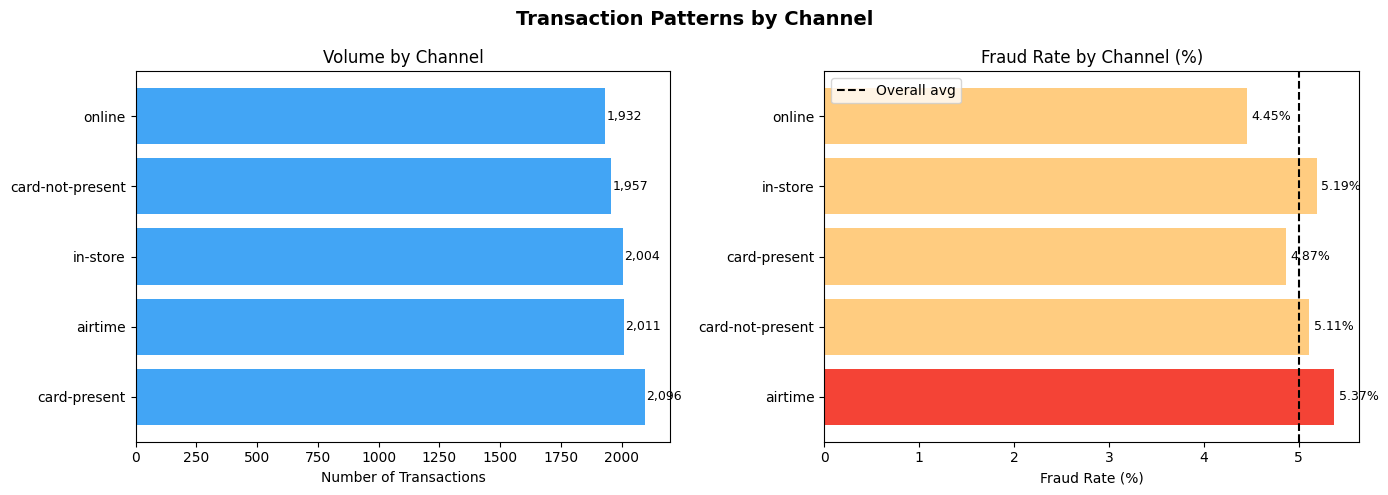


 Key insight: Airtime channel has the highest fraud rate at 5.37%.


In [ ]:
# Transaction Channel Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Patterns by Channel', fontsize=14, fontweight='bold')

channel_vol = df['transaction_channel'].value_counts()
channel_fraud = df.groupby('transaction_channel')['is_fraud'].mean() * 100

# Volume
axes[0].barh(channel_vol.index, channel_vol.values, color='#42A5F5')
axes[0].set_title('Volume by Channel')
axes[0].set_xlabel('Number of Transactions')
for i, v in enumerate(channel_vol.values):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Fraud rate
colors = ['#f44336' if v == channel_fraud.max() else '#FFCC80' for v in channel_fraud.values]
axes[1].barh(channel_fraud.index, channel_fraud.values, color=colors)
axes[1].set_title('Fraud Rate by Channel (%)')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].axvline(df['is_fraud'].mean()*100, color='black', linestyle='--', label='Overall avg')
axes[1].legend()
for i, v in enumerate(channel_fraud.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Key insight: Airtime channel has the highest fraud rate at 5.37%.")

# High transaction amounts Vs Fraud
Transaction amounts are one of the strongest indicators of fraud in this dataset. We first replace the 999999 placeholder values with 0, as these could represent failed or null transactions. The charts show that fraudulent transactions have a significantly higher average amount than legitimate ones, and that transactions above R1000 carry a fraud rate of 85.1% making high transaction value one of the clearest red flags in the data.

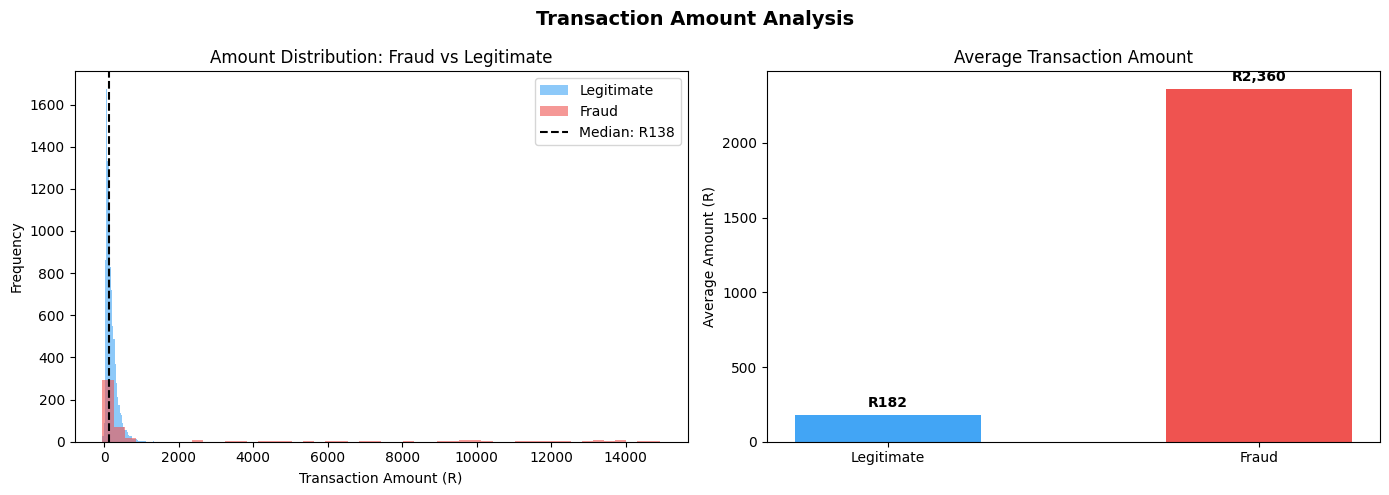

Fraud average: R2,360 vs Legitimate average: R182
Transactions above R1000 have a fraud rate of 85.1%


In [ ]:
# Transaction Amount Distribution

# Replace 999999 with 0 (failed/null transactions)
df.loc[df['amount'] == 999999, 'amount'] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')

# Distribution
axes[0].hist(df[df['is_fraud']==0]['amount'], bins=50,
             alpha=0.6, color='#42A5F5', label='Legitimate')
axes[0].hist(df[df['is_fraud']==1]['amount'], bins=50,
             alpha=0.6, color='#EF5350', label='Fraud')
axes[0].axvline(df['amount'].median(), color='black', linestyle='--',
                label=f'Median: R{df["amount"].median():.0f}')
axes[0].set_title('Amount Distribution: Fraud vs Legitimate')
axes[0].set_xlabel('Transaction Amount (R)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Average by fraud label
avg_amounts = df.groupby('is_fraud')['amount'].mean()
bars = axes[1].bar(['Legitimate', 'Fraud'], avg_amounts.values,
                   color=['#42A5F5', '#EF5350'], width=0.5)
axes[1].set_title('Average Transaction Amount')
axes[1].set_ylabel('Average Amount (R)')
for bar, val in zip(bars, avg_amounts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 50,
                 f'R{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

fraud_rate_high = df[df['amount'] > 1000]['is_fraud'].mean() * 100
print(f"Fraud average: R{avg_amounts[1]:,.0f} vs Legitimate average: R{avg_amounts[0]:,.0f}")
print(f"Transactions above R1000 have a fraud rate of {fraud_rate_high:.1f}%")

# Hour of day Vs Fraud
Timing plays an important role in fraud detection. This chart overlays transaction volume and fraud rate across each hour of the day. Both peak at 2AM, which falls within the high-risk window of 1–5AM. This suggests that fraudsters are most active in the early hours of the morning when monitoring may be less vigilant.

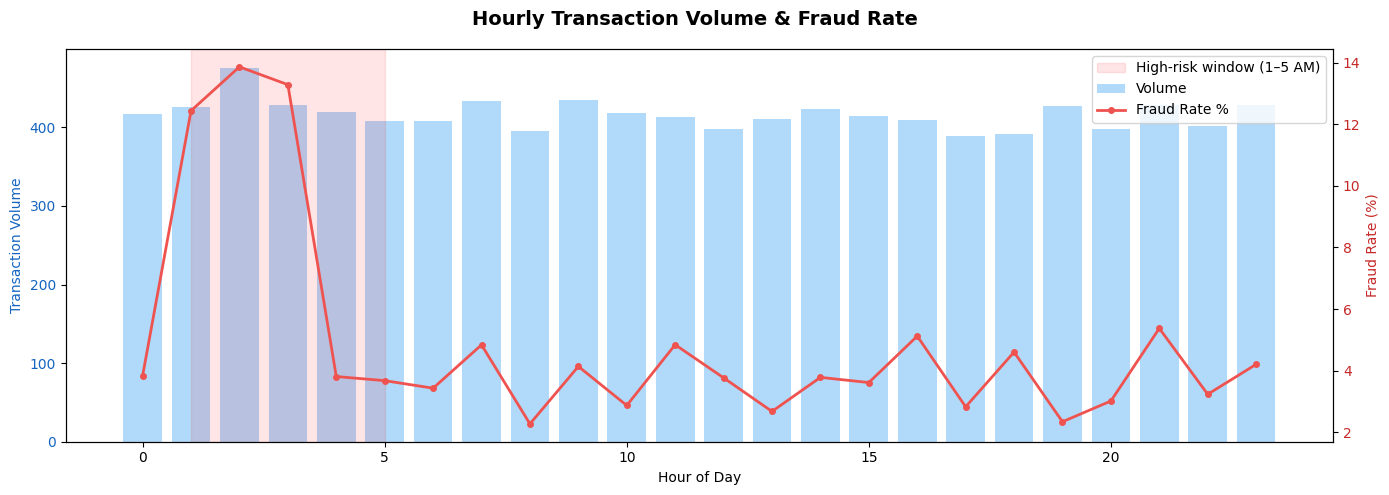


 Key insight: Transaction volume and fraud rate peak at 2AM.
 Night transactions (1–5AM) fraud rate: 5.35%


In [ ]:
# Time of Day Analysis
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

hourly = df.groupby('hour').agg(
    total=('is_fraud', 'count'),
    fraud_rate=('is_fraud', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle('Hourly Transaction Volume & Fraud Rate', fontsize=14, fontweight='bold')

ax1.bar(hourly['hour'], hourly['total'], color='#90CAF9', alpha=0.7, label='Volume')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Volume', color='#1565C0')
ax1.tick_params(axis='y', labelcolor='#1565C0')

ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['fraud_rate']*100, color='#EF5350',
         marker='o', linewidth=2, markersize=4, label='Fraud Rate %')
ax2.set_ylabel('Fraud Rate (%)', color='#C62828')
ax2.tick_params(axis='y', labelcolor='#C62828')

ax1.axvspan(1, 5, alpha=0.1, color='red', label='High-risk window (1–5 AM)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('hourly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Key insight: Transaction volume and fraud rate peak at 2AM.")
print(f" Night transactions (1–5AM) fraud rate: {df[df['is_night']==1]['is_fraud'].mean()*100:.2f}%")

# Distance and Time Gap Analysis
These two charts examine how location jumps and transaction speed relate to fraud. A transaction appearing thousands of kilometres away from the previous one within minutes is physically impossible and a strong fraud signal. Similarly, very fast back to back transactions under 5 minutes could suggest automated or bot driven fraud activity

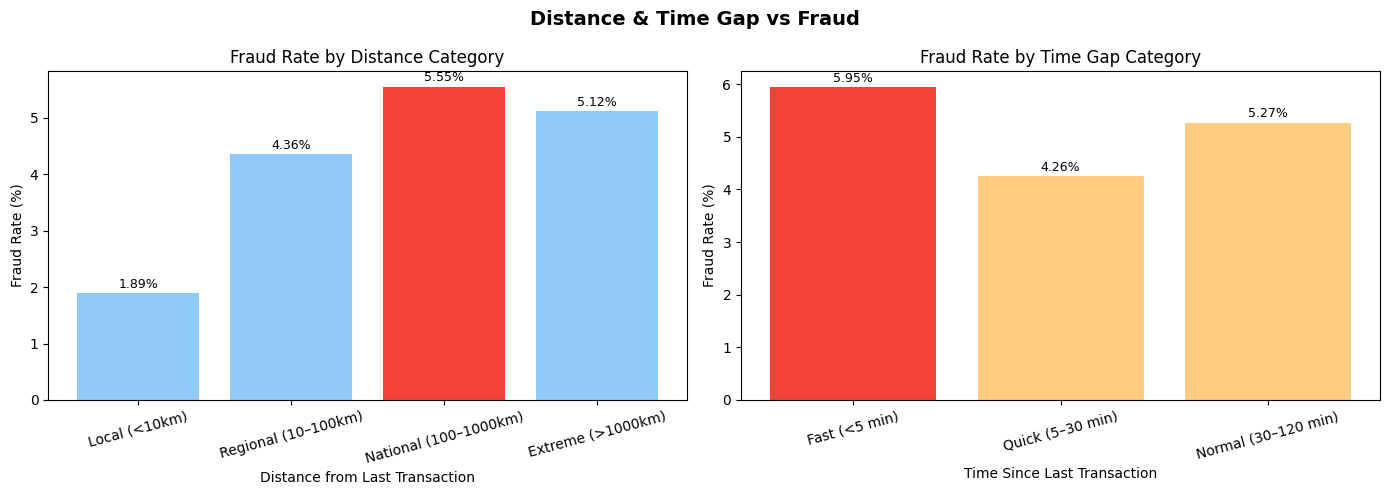


 Key insight: Extreme distances (>1000km) have the highest fraud rate.
 Fast transactions (<5 min) fraud rate peaks at 5.95%


In [ ]:
# Distance & Time Gap Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distance & Time Gap vs Fraud', fontsize=14, fontweight='bold')

# Distance categories
df['distance_category'] = pd.cut(
    df['distance_from_last_tx'],
    bins=[-1, 10, 100, 1000, float('inf')],
    labels=['Local (<10km)', 'Regional (10–100km)', 'National (100–1000km)', 'Extreme (>1000km)']
)
dist_fraud = df.groupby('distance_category', observed=True)['is_fraud'].mean() * 100
colors = ['#f44336' if v == dist_fraud.max() else '#90CAF9' for v in dist_fraud.values]
axes[0].bar(dist_fraud.index, dist_fraud.values, color=colors)
axes[0].set_title('Fraud Rate by Distance Category')
axes[0].set_xlabel('Distance from Last Transaction')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(dist_fraud.values):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

# Time gap categories
df['time_gap_min'] = df['time_since_last_tx'] / 60
df['time_gap_cat'] = pd.cut(
    df['time_gap_min'],
    bins=[-1, 5, 30, 120, float('inf')],
    labels=['Fast (<5 min)', 'Quick (5–30 min)', 'Normal (30–120 min)', 'Slow (>120 min)']
)
time_fraud = df.groupby('time_gap_cat', observed=True)['is_fraud'].mean() * 100
colors2 = ['#f44336' if v == time_fraud.max() else '#FFCC80' for v in time_fraud.values]
axes[1].bar(time_gap_cat := time_fraud.index, time_fraud.values, color=colors2)
axes[1].set_title('Fraud Rate by Time Gap Category')
axes[1].set_xlabel('Time Since Last Transaction')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(time_fraud.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distance_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Key insight: National distances (100km-1000km) have the highest fraud rate.")
print(f" Fast transactions (<5 min) fraud rate peaks at {time_fraud.iloc[0]:.2f}%")

# High Risk Combination patterns
It is usually a combination of suspicious behaviours occurring together that can lead to higher fraud rates. This chart shows that when risk factors are combined, fraud rates can spike well above the 5% baseline. A device change paired with a fast transaction, or a high-risk merchant paired with a large amount, are far more telling than either signal on its own.

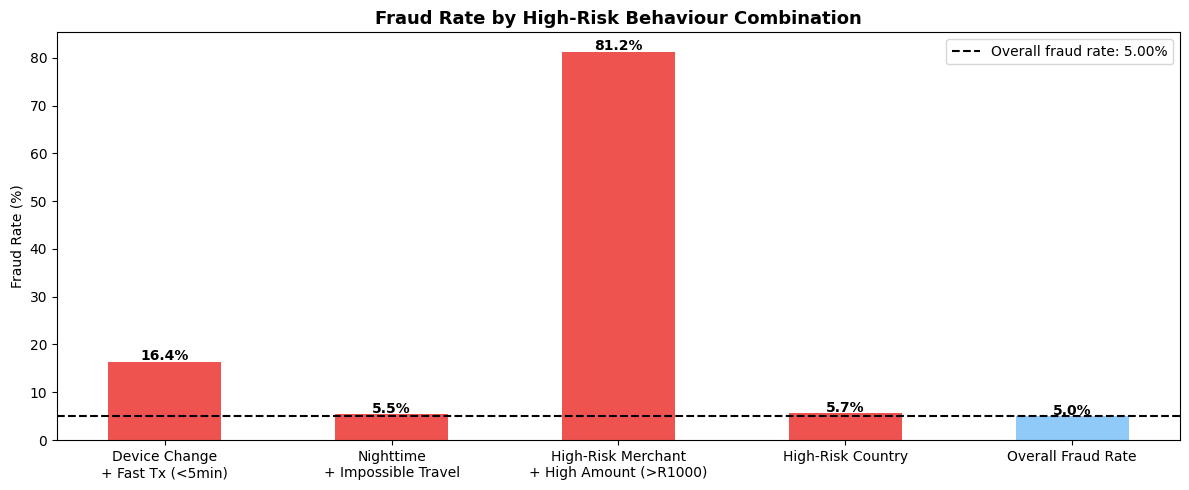


 Key findings:
  Device change + fast tx fraud rate: 16.4%
  High-risk merchant + high amount:   81.2%
  Both are far above the 5% baseline.


In [ ]:
# High-Risk Combination Patterns
combos = {
    'Device Change\n+ Fast Tx (<5min)':
        df[(df['device_change']==1) & (df['time_gap_min']<5)]['is_fraud'].mean()*100,

    'Nighttime\n+ Impossible Travel':
        df[(df['is_night']==1) & (df['km_per_min']>=15)]['is_fraud'].mean()*100,

    'High-Risk Merchant\n+ High Amount (>R1000)':
        df[(df['merchant_risk_score']==3) & (df['amount']>1000)]['is_fraud'].mean()*100,

    'High-Risk Country':
        df[df['high_risk_country']==1]['is_fraud'].mean()*100,

    'Overall Fraud Rate':
        df['is_fraud'].mean()*100
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#EF5350' if v > combos['Overall Fraud Rate'] else '#90CAF9' for v in combos.values()]
bars = ax.bar(combos.keys(), combos.values(), color=colors, width=0.5)
ax.axhline(combos['Overall Fraud Rate'], color='black', linestyle='--', linewidth=1.5,
           label=f"Overall fraud rate: {combos['Overall Fraud Rate']:.2f}%")
ax.set_title('Fraud Rate by High-Risk Behaviour Combination', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
ax.legend()
for bar, val in zip(bars, combos.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('risk_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Key findings:")
print(f"  Device change + fast tx fraud rate: {combos['Device Change\n+ Fast Tx (<5min)']:.1f}%")
print(f"  High-risk merchant + high amount:   {combos['High-Risk Merchant\n+ High Amount (>R1000)']:.1f}%")
print(f"  Both are far above the 5% baseline.")

#Simple Model
The most relevant features identified during the EDA are selected and split the data into a training set (80%) and a testing set (20%). The model learns patterns from the training set and is evaluated on the unseen testing set to measure how well it generalises to new data.

In [ ]:
#Prepare Data for Modelling
from sklearn.model_selection import train_test_split

# Select features
features = [
    'amount', 'device_change', 'is_night', 'merchant_risk_score',
    'high_risk_country', 'distance_from_last_tx', 'km_per_min',
    'velocity_last_10min', 'prior_chargebacks', 'account_age_days'
]

X = df[features]
y = df['is_fraud']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")

Training set size: 8,000 rows
Testing set size:  2,000 rows


StandardScaler is used to bring all features onto the same scale before training. The model then learns the probability that any given transaction is fraudulent based on the weighted combination of these features.

In [ ]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

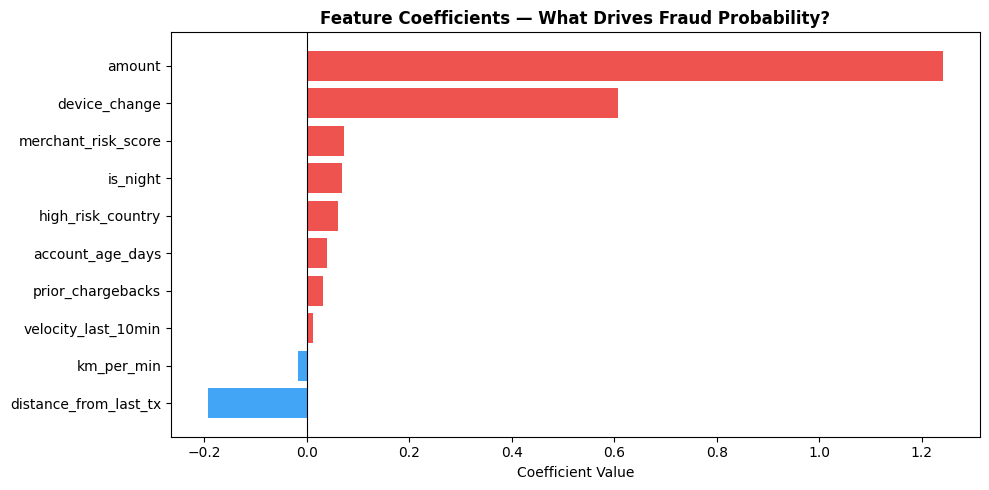

Red bars = increases fraud probability
Blue bars = decreases fraud probability


In [ ]:
#Feature Coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['#EF5350' if c > 0 else '#42A5F5' for c in coefficients['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — What Drives Fraud Probability?', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("Red bars = increases fraud probability")
print("Blue bars = decreases fraud probability")

#Model Perfomance
The confusion matrix breaks down the model's predictions into four outcomes : correctly identified legitimate transactions, correctly identified fraud, legitimate transactions wrongly flagged as fraud (false positives), and actual fraud the model missed (false negatives). In a business context, false negatives are the most dangerous outcome as they represent fraud that slips through undetected. The standard 0.5 threshold was used, achieving 89% accuracy and catching 58% of fraud cases. The class imbalance in the dataset is the primary limitation, and more advanced models such as Random Forest or XGBoost would be recommended for production

Accuracy: 88.95%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.91      0.94      1901
       Fraud       0.24      0.58      0.34        99

    accuracy                           0.89      2000
   macro avg       0.61      0.74      0.64      2000
weighted avg       0.94      0.89      0.91      2000



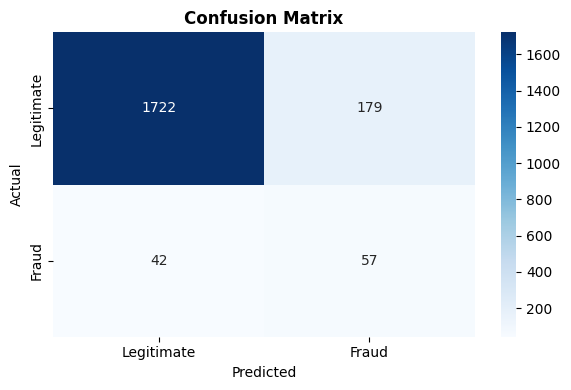

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

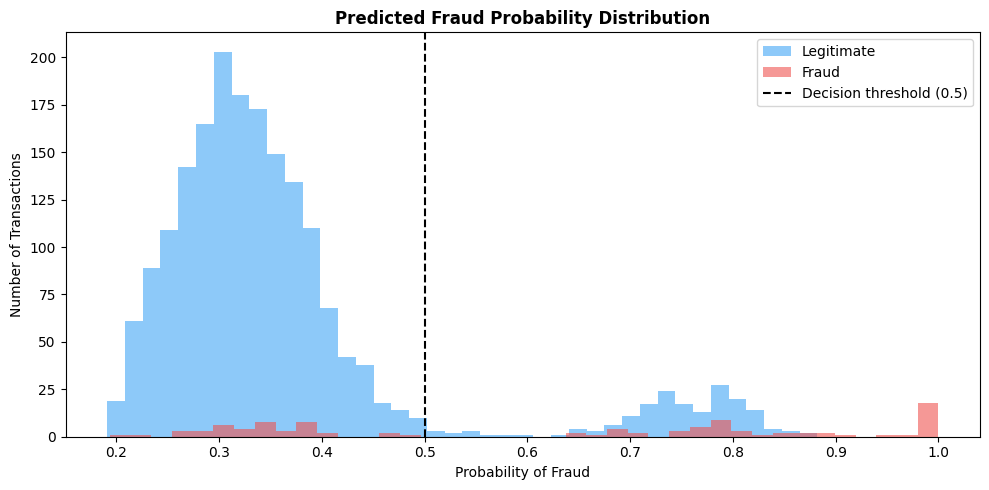

In [ ]:
# Fraud Probability Scores
y_proba = model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10, 5))
plt.hist(y_proba[y_test == 0], bins=40, alpha=0.6,
         color='#42A5F5', label='Legitimate')
plt.hist(y_proba[y_test == 1], bins=40, alpha=0.6,
         color='#EF5350', label='Fraud')
plt.axvline(0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
plt.title('Predicted Fraud Probability Distribution', fontweight='bold')
plt.xlabel('Probability of Fraud')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()